# Análise de dataficação em diferentes temas - Congresso ALAS 2026

In [42]:
import re
import pandas as pd
import matplotlib.pyplot as pl
import numpy as np

import brass as br
import xavy.plots as xp

import clean as cl
import datausage as du

## Carregando dados - Agrupando bases originais e do GPT

In [2]:
# Trabalhos acadêmicos analisados (dados de entrada):
folder = '../dados/dspaces/samples/'
sample_files = ["tccs-teses-dissertacoes-outros_ufam_2020-2025_n472_s01.csv", # 7.0% dos trabalhos entre 2020 e 2025 da UF.
                "tccs-teses-dissertacoes_ufcg_2020-2025_n569_s01.csv",        # 7.0% dos trabalhos entre 2020 e 2025 da UF.
                "tccs-teses-dissertacoes_ufes_2020-2025_n323_s01.csv",        # 7.0% dos trabalhos entre 2020 e 2025 da UF.
                "tccs-teses-dissertacoes_ufrgs_2020-2025_n883_s01.csv"]       # 3.5% dos trabalhos entre 2020 e 2025 da UF.

In [3]:
# Subconjunto da UFRGS que foi analisada manualmente até a data de análise:
uri_manual = pd.read_csv('../dados/dspaces/samples/aux/urfgs-uris-analisadas-manualmente_2026-05-28.txt', names=['uri'])['uri']
uri_manual = uri_manual.str.replace('http://', 'https://')

In [4]:
# Carrega e junta avaliação da IA:
sel_cols = ['titulo', 'autoria', 'uf', 'resumo', 'uri', 'type_pred', 'topics_pred', 'geo_level_pred', 'y_pred']
results = []
for i in range(len(sample_files)):
    
    # Seleciona arquivo de UF:
    f = folder + sample_files[i]
    uf = re.search('_(uf[a-z]{1,4})_', sample_files[i]).group(1).upper()
    print(uf)
    
    # Carrega os temas e outros metadados criados pelo LLM:
    gpt_jsonl_in  = du.in2out_name(f, in_suffix='.csv', out_suffix='_metadata_gpt-in.jsonl')
    gpt_jsonl_out = du.in2out_name(gpt_jsonl_in)
    single_df = du.build_results_csv(f, gpt_jsonl_in, gpt_jsonl_out, application='metadata_collection')
    # Processa metadados:
    single_df.rename({'uri_link': 'uri'}, axis=1, inplace=True)
    single_df['uri'] = single_df['uri'].str.replace('http://', 'https://')
    single_df['uf'] = uf

    # Carrega identificação via LLM de uso de dados públicos:
    gpt_jsonl_in  = du.in2out_name(f, in_suffix='.csv', out_suffix='_gpt-in.jsonl')
    gpt_jsonl_out = du.in2out_name(gpt_jsonl_in)
    y_df = du.build_results_csv(f, gpt_jsonl_in, gpt_jsonl_out, application='usecase_detection')
    # Processa base:
    y_df.rename({'uri_link': 'uri'}, axis=1, inplace=True)
    y_df['uri'] = y_df['uri'].str.replace('http://', 'https://')
    y_df = y_df.set_index('uri')['y_pred']

    # Junta predição de uso de dados com temas e outros metadados:
    single_df = single_df.join(y_df, on='uri')
    
    # Acumula resultados da UF em lista:
    results.append(single_df[sel_cols])

# Concatena UFs:
results_df = pd.concat(results, ignore_index=True)
# Seleciona apenas as verificadas manualmente da UFRGS:
verified_df = results_df.loc[((results_df['uf'] != 'UFRGS') | (results_df['uri'].isin(uri_manual)))]

UFAM
UFCG
UFES
UFRGS


In [5]:
# Carrega anotações manuais sobre os casos de uso:
cordata = cl.load_json('../dados/backups/usecases_bkp_2026-06-02.json')
usecases = cordata['data']
usecases_df = pd.DataFrame(usecases)
usecases_df['url'] = usecases_df['url'].str.replace('http://', 'https://')
usecases_df['y_annot'] = 1
usecases_df.rename({'topics':'topics_annot'}, axis=1, inplace=True)
academic_df = usecases_df.loc[usecases_df['type'].apply(lambda s: 'artigo científico ou publicação acadêmica' in s if type(s) == list else False)]

In [6]:
# Nenhum trabalho catalogado no cordata ficou de fora da nossa análise:
assert 0 == pd.Series(list(set(academic_df['url']) - set(verified_df['uri']))).str.contains('ufam|ufcg|ufes|ufrgs', regex=True).sum()

# Junta anotações manuais com base completa:
pred_annot_df = verified_df.join(academic_df.set_index('url')[['topics_annot', 'y_annot']], on='uri')
pred_annot_df['y_annot'] = pred_annot_df['y_annot'].fillna(0).astype(int)

# Classificação sobre uso de dados públicos após sistema LLM + revisão manual:
pred_annot_df['y_final'] = pred_annot_df['y_pred'] * pred_annot_df['y_annot']
# Usa avaliação manual onde houver, senão usa automática:
pred_annot_df['topics_final'] = pred_annot_df['topics_pred'].where(pred_annot_df['topics_annot'].isnull(), pred_annot_df['topics_annot'])

Vamos considerar os vinte temas mais trabalhados:

# de trabalhos acadêmicos considerados: 1769


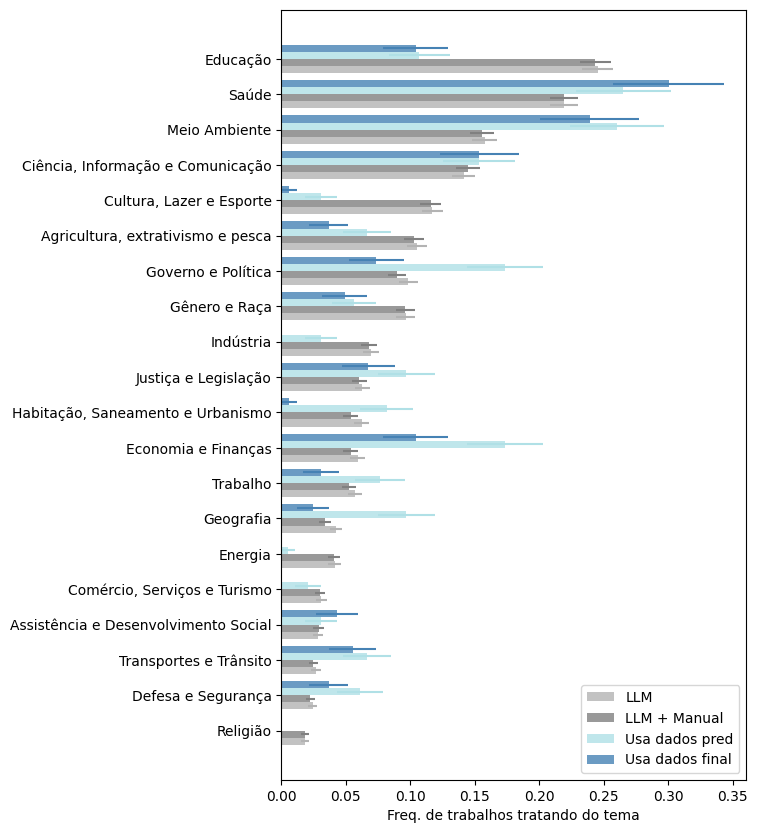

In [48]:
opts = ['pred', 'final']
top_k = 20
pred_counts = pred_annot_df['topics_pred'].explode().value_counts().head(top_k)
n_all = len(pred_annot_df)
topics_list = list(pred_counts.index)
print('# de trabalhos acadêmicos considerados:', n_all)
final_counts = pred_annot_df['topics_final'].explode().value_counts().loc[topics_list]
counts_df = pd.DataFrame(columns=['LLM', 'LLM + Manual'])
counts_df['LLM'] = pred_counts
counts_df['LLM + Manual'] = final_counts
counts_df.sort_values('LLM', inplace=True)

freqs_df = counts_df / n_all

freq_err_df = pd.DataFrame()
freq_err_df['LLM'] = np.sqrt(counts_df['LLM']) / n_all
freq_err_df['LLM + Manual'] = np.sqrt(counts_df['LLM + Manual']) / n_all

for opt in opts:
    use_df = pred_annot_df.loc[pred_annot_df['y_' + opt] == 1]
    use_counts = use_df['topics_' + opt].explode().value_counts()
    use_counts = use_counts.loc[use_counts.index.isin(topics_list)]
    n_use = len(use_df)
    counts_df['Usa dados ' + opt] = use_counts
    counts_df['Usa dados ' + opt] = counts_df['Usa dados ' + opt].fillna(0).astype(int)
    freqs_df['Usa dados ' + opt]  = use_counts / n_use
    freqs_df['Usa dados ' + opt] = freqs_df['Usa dados ' + opt].fillna(0)
    
    freq_err_df['Usa dados ' + opt] = np.sqrt(counts_df['Usa dados ' + opt]) / n_use

pl.figure(figsize=(6,10))
xp.multiple_bars_plot(freqs_df, horizontal=True, err=freq_err_df, colors=['0.7', '0.5', 'powderblue', 'steelblue'], alpha=0.8)
pl.legend()
pl.xlabel('Freq. de trabalhos tratando do tema')
pl.show()

## Análise de associação entre uso de dados públicos e temas

In [9]:
# Loop sobre método de rotulação (automático, automático + manual):
methods = dict()
for opt in opts:
    # Loop sobre temas:
    dfs = []
    for topic in topics_list:
        # Seleciona colunas (uso de dados e tema):
        col_A = 'y_' + opt
        col_B = topic
        pair_df = pred_annot_df[[col_A]]
        pair_df[col_B] = pred_annot_df['topics_' + opt].apply(lambda s: col_B in s).astype(int)
        # Roda teste estatístico de associação:
        estimator = br.AssocEstimator(onehot_trials=pair_df)
        chain_df = estimator.sample_model()
        df = estimator.summarize_stats(chain_df, 'Usa dados', col_B)
        dfs.append(df)
    # Junta resultados dos temas:
    assoc_df = pd.concat(dfs, axis=0)
    methods[] = assoc_df

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   3500        0           0.290       15          1268.72 draws/s      0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   3500        0           0.263       3           1185.08 draws/s      0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   3500        0           0.449       7           1134.00 draws/s      0:00:03    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   3500        0           0.250       13          1073.53 draws/s      0:00:03    0:00:00

Sampling 4 chains for 1_000 tune and 2_500 draw iterations (4_000 + 10_000 draws total) took 3 seconds.


In [13]:
alpha_single = 0.05
alpha_bonferroni = alpha_single / len(topics_list)

detected = dict()
undetected = dict()
positive_assoc = dict()
negative_assoc = dict()
for opt in opts:
    detected[opt] = methods[opt].loc[methods[opt]['delta p-value'] < alpha_bonferroni]
    undetected[opt] = methods[opt].loc[methods[opt]['delta p-value'] > alpha_bonferroni]
    positive_assoc[opt] = detected[opt].loc[detected[opt]['deltaP(A,B)'] > 0]
    negative_assoc[opt] = detected[opt].loc[detected[opt]['deltaP(A,B)'] < 0]

In [19]:
positive_topics = set(positive_assoc['pred'].query('Direction == "F"')['B']) & set(positive_assoc['final'].query('Direction == "F"')['B'])
negative_topics = set(negative_assoc['pred'].query('Direction == "F"')['B']) & set(negative_assoc['final'].query('Direction == "F"')['B'])

In [22]:
positive_assoc['final'].loc[positive_assoc['final']['B'].isin(positive_topics)].sort_values('P(A|B)', ascending=False)

,Direction,A,B,P(A),dev P(A),P(A|B),dev P(A|B),"deltaP(A,B)","dev deltaP(A,B)",abs delta nsigma,delta p-value
0,F,Usa dados,Meio Ambiente,0.093065,0.006937,0.144147,0.021194,0.051082,0.018828,2.713055,0.0015


In [23]:
negative_assoc['final'].loc[negative_assoc['final']['B'].isin(negative_topics)].sort_values('P(A|B)', ascending=False)

,Direction,A,B,P(A),dev P(A),P(A|B),dev P(A|B),"deltaP(A,B)","dev deltaP(A,B)",abs delta nsigma,delta p-value
0,F,Usa dados,Educação,0.092924,0.006822,0.041120,0.009655,-0.051804,0.009741,5.317930,0.0000
0,F,Usa dados,Energia,0.093139,0.006915,0.013255,0.012938,-0.079885,0.014201,5.625087,0.0007
0,F,Usa dados,"Cultura, Lazer e Esporte",0.093154,0.006910,0.009857,0.006857,-0.083297,0.009096,9.157403,0.0000


# Lixo

In [14]:
n_samples = 10000
samples = []
for i in range(n_samples):
    s = verified_df.sample(n_use_pred)['topics_pred'].explode().value_counts()
    s.name = i
    samples.append(s)

samples_df = pd.concat(samples, axis=1).fillna(0).astype(int)
samples_df = samples_df.loc[samples_df.index.isin(all_counts.index)]

In [27]:
samples_df

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
topics_pred,,,,,,,,,,,,,,,,,,,,,
Educação,46,53,54,43,41,53,45,52,46,55,...,40,45,50,48,52,45,56,48,47,37
Saúde,46,39,39,40,53,34,46,36,43,42,...,48,49,41,46,38,47,39,58,50,41
"Ciência, Informação e Comunicação",26,35,27,22,20,27,26,23,30,29,...,18,24,22,29,23,38,22,25,24,24
"Cultura, Lazer e Esporte",26,24,26,25,21,23,27,24,23,23,...,16,19,27,32,21,22,27,14,21,25
Governo e Política,24,14,14,15,20,25,19,23,22,23,...,22,21,15,17,15,21,18,17,18,20
Meio Ambiente,24,27,34,30,23,26,36,33,32,28,...,28,36,40,37,30,32,31,36,30,34
Gênero e Raça,23,21,25,22,19,14,22,15,24,10,...,17,22,18,16,21,22,22,18,18,23
Indústria,19,16,12,11,15,17,12,20,14,10,...,15,10,13,16,12,17,14,15,14,12
"Agricultura, extrativismo e pesca",18,20,17,20,21,23,14,27,14,16,...,22,20,28,26,27,18,22,22,23,23


In [28]:
use_pred_counts

topics_pred
Saúde                                   52
Meio Ambiente                           51
Economia e Finanças                     34
Governo e Política                      34
Ciência, Informação e Comunicação       30
Educação                                21
Justiça e Legislação                    19
Geografia                               19
Habitação, Saneamento e Urbanismo       16
Trabalho                                15
Agricultura, extrativismo e pesca       13
Transportes e Trânsito                  13
Defesa e Segurança                      12
Gênero e Raça                           11
Assistência e Desenvolvimento Social     6
Cultura, Lazer e Esporte                 6
Indústria                                6
Comércio, Serviços e Turismo             4
Energia                                  1
Name: count, dtype: int64

In [23]:
samples_df

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
topics_pred,,,,,,,,,,,,,,,,,,,,,
Educação,46,53,54,43,41,53,45,52,46,55,...,40,45,50,48,52,45,56,48,47,37
Saúde,46,39,39,40,53,34,46,36,43,42,...,48,49,41,46,38,47,39,58,50,41
"Ciência, Informação e Comunicação",26,35,27,22,20,27,26,23,30,29,...,18,24,22,29,23,38,22,25,24,24
"Cultura, Lazer e Esporte",26,24,26,25,21,23,27,24,23,23,...,16,19,27,32,21,22,27,14,21,25
Governo e Política,24,14,14,15,20,25,19,23,22,23,...,22,21,15,17,15,21,18,17,18,20
Meio Ambiente,24,27,34,30,23,26,36,33,32,28,...,28,36,40,37,30,32,31,36,30,34
Gênero e Raça,23,21,25,22,19,14,22,15,24,10,...,17,22,18,16,21,22,22,18,18,23
Indústria,19,16,12,11,15,17,12,20,14,10,...,15,10,13,16,12,17,14,15,14,12
"Agricultura, extrativismo e pesca",18,20,17,20,21,23,14,27,14,16,...,22,20,28,26,27,18,22,22,23,23
